## Actividad 3_10

<div style="border-style:groove;border-width:thin;padding:10px">

En esta actividad vamos a tratar de solucionar un problema mediante clasificación, aunque también podría tratarse como regresión. 
Se trata de un dataset de valoración de vinos. 

<p style="border-style:groove;border-width:thin;padding:10px">
Lo primero que vamos a hacer es importar los datos y analizar el dataset que tenemos.
</p>

In [1]:
import pandas as pd
vinos = pd.read_csv('winequalityN.csv')
vinos.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6.0
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6.0
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6.0
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6.0
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6.0


In [4]:
vinos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6479 non-null   float64
dtypes: float64(12), object(1)
memory usage: 660.0+ KB


Características del dataset:
<ul>
<li>La columna quality nos da la puntuación de calidad que le dan al vino. Queremos predecirla en función de las características del vino. </li>
<li>Tenemos, además de nulos, 7 posibles valores. Se podría hacer como un problema de regresión o como uno de clasificación de 7 clases.</li>
</ul>
</div>

Prepara el dataset para poder resolverlo con los dos algoritmos de clasificación que hemos visto, decision tree y SVC. Cuidado con los nulos, trátalos de la forma adecuada. Haz la correlación de las variables con la variable objetivo para ir intuyendo lo que podremos conseguir. Trabaja con los hiperparámetros para conseguir el mejor resultado posible. Valora los resultados y haz los cambios que consideres oportunos.

In [5]:
vinos.dropna(inplace=True)

In [6]:
vinos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6445 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6445 non-null   object 
 1   fixed acidity         6445 non-null   float64
 2   volatile acidity      6445 non-null   float64
 3   citric acid           6445 non-null   float64
 4   residual sugar        6445 non-null   float64
 5   chlorides             6445 non-null   float64
 6   free sulfur dioxide   6445 non-null   float64
 7   total sulfur dioxide  6445 non-null   float64
 8   density               6445 non-null   float64
 9   pH                    6445 non-null   float64
 10  sulphates             6445 non-null   float64
 11  alcohol               6445 non-null   float64
 12  quality               6445 non-null   float64
dtypes: float64(12), object(1)
memory usage: 704.9+ KB


In [7]:
vinos = pd.get_dummies(vinos,dtype=int)

In [8]:
vinos.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type_red,type_white
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6.0,0,1
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6.0,0,1
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6.0,0,1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6.0,0,1
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6.0,0,1


In [14]:
vinos.corr()['quality'].abs().sort_values(ascending=False)[1:]

alcohol                 0.444986
density                 0.304342
volatile acidity        0.265735
chlorides               0.199723
type_white              0.118791
type_red                0.118791
citric acid             0.084799
fixed acidity           0.075812
free sulfur dioxide     0.054267
total sulfur dioxide    0.041668
sulphates               0.039172
residual sugar          0.034995
pH                      0.017710
Name: quality, dtype: float64

In [15]:
X = vinos.drop(['quality'],axis=1)
y = vinos['quality'].to_frame()

In [16]:
from sklearn.preprocessing import StandardScaler
escalador = StandardScaler()
X = escalador.fit_transform(X)

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)

In [18]:
from sklearn.tree import DecisionTreeClassifier
tree_clf = DecisionTreeClassifier()
#tree_clf = DecisionTreeClassifier(max_depth=3)
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier()

In [19]:
y_pred = tree_clf.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.6105508145849495

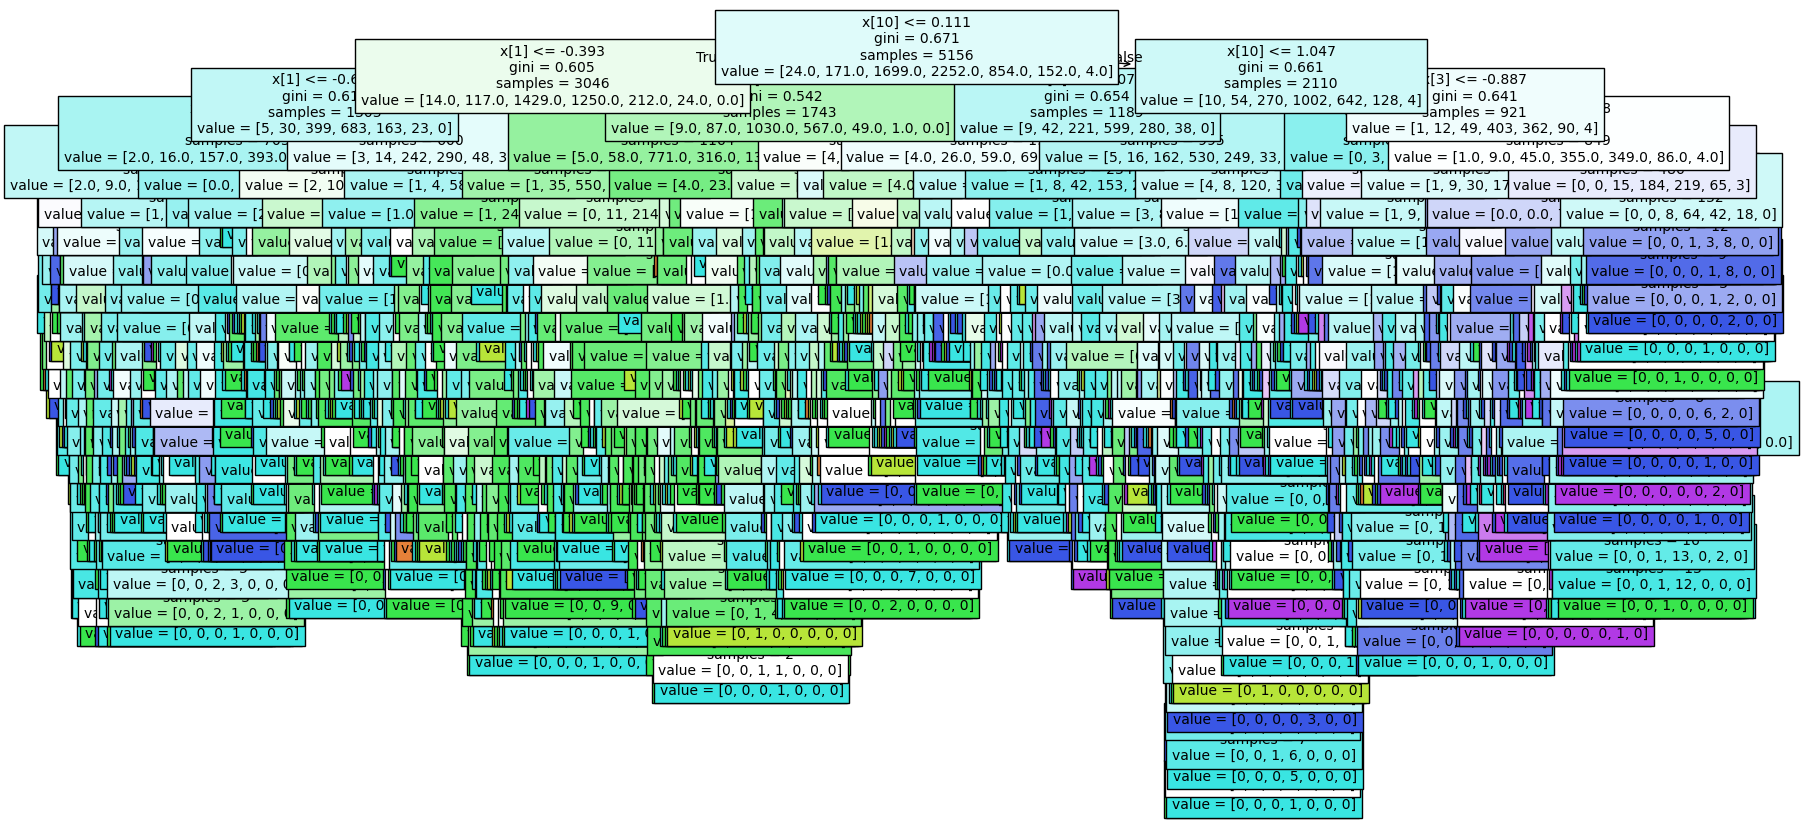

In [20]:
# Visualizar el árbol (solo primeros niveles por tamaño)
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 10))
from sklearn.tree import plot_tree
plot_tree(tree_clf, 
          filled=True, 
          #feature_names=[f"pixel_{i}" for i in range(784)],
          #class_names=[str(i) for i in range(10)],
          #max_depth=3,  # Solo 2 niveles para que se vea
          fontsize=10)
plt.title("Árbol de Decisión MNIST (primeros 3 niveles)")
plt.show()

In [21]:
from sklearn.svm import SVC
clasificador = SVC(kernel='rbf',C=1)
clasificador.fit(X_train,y_train)
y_pred = clasificador.predict(X_test)
accuracy_score(y_test,y_pred)

c:\Users\Equipo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.5903801396431342